In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gensim

In [ ]:
file_path = '/content/drive/MyDrive/mental-health-sentiment/mental-data.csv'
df = pd.read_csv(file_path)

df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


### **EDA**

In [ ]:
print(df.isnull().sum())


Unnamed: 0      0
statement     362
status          0
dtype: int64


/tmp/ipykernel_754/1530478895.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='status', order=df['status'].value_counts().index, palette='viridis')


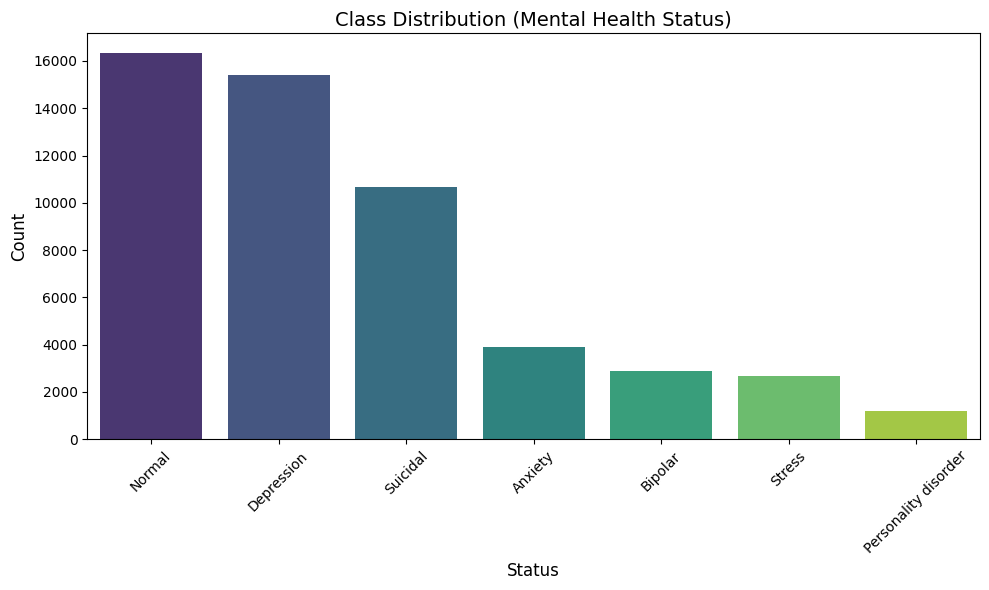

,Count,Percentage (%)
status,,
Normal,16351,30.83
Depression,15404,29.04
Suicidal,10653,20.08
Anxiety,3888,7.33
Bipolar,2877,5.42
Stress,2669,5.03
Personality disorder,1201,2.26


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='status', order=df['status'].value_counts().index, palette='viridis')
plt.title('Class Distribution (Mental Health Status)', fontsize=14)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

class_counts = df['status'].value_counts()
class_percentages = df['status'].value_counts(normalize=True) * 100
balance_df = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_percentages.round(2)})
display(balance_df)

/tmp/ipykernel_754/4163282360.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y='word_count', palette='Set2')


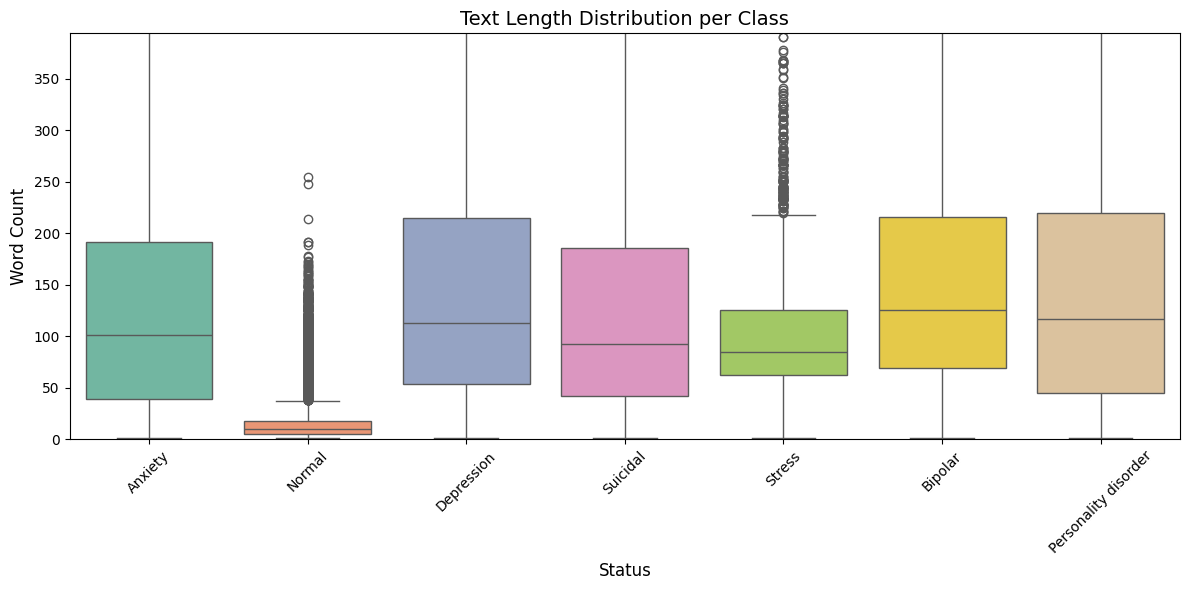

Median Word Count per Class:
status
Anxiety                 101.0
Bipolar                 125.0
Depression              113.0
Normal                   10.0
Personality disorder    117.0
Stress                   85.0
Suicidal                 92.0
Name: word_count, dtype: float64


In [ ]:
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='status', y='word_count', palette='Set2')
plt.title('Text Length Distribution per Class', fontsize=14)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Word Count', fontsize=12)

plt.ylim(0, df['word_count'].quantile(0.95))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Median Word Count per Class:")
print(df.groupby('status')['word_count'].median())

In [ ]:
df['clean_statement'] = df['statement'].astype(str).str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()

# Count Exact Duplicates
exact_duplicates = df.duplicated(subset=['clean_statement']).sum()
total_rows = len(df)
dup_percentage = (exact_duplicates / total_rows) * 100

print("Duplicate Audit")
print(f"Total Rows: {total_rows}")
print(f"Exact Duplicates Found: {exact_duplicates}")
print(f"Percentage of Dataset Duplicated: {dup_percentage:.2f}%\n")

# example of a duplicated row
if exact_duplicates > 0:
    print("Example of duplicated statements:")
    duplicates_df = df[df.duplicated(subset=['clean_statement'], keep=False)].sort_values(by='clean_statement')
    display(duplicates_df[['status', 'statement']].head(4))

Duplicate Audit
Total Rows: 53043
Exact Duplicates Found: 1998
Percentage of Dataset Duplicated: 3.77%

Example of duplicated statements:


,status,statement
53027,Anxiety,"""Buy Friends"" comment? My mother doesn't have ..."
52041,Anxiety,"""Buy Friends"" comment? My mother doesn't have ..."
49300,Stress,"""Desk Toys for Your Stressful Day!"" \n\nDesk ..."
48420,Stress,"""Desk Toys for Your Stressful Day!"" \n\nDesk ..."


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
vectorizer.fit(df['clean_statement'])

vocab_size = len(vectorizer.vocabulary_)
print(f"Total Vocabulary Size (Unique Words): {vocab_size}")

# top 20 most frequent words in the ENTIRE dataset
X_all = vectorizer.transform(df['clean_statement'])
word_freq_all = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'freq': X_all.sum(axis=0).A1
}).sort_values(by='freq', ascending=False)

print("\nTop 20 words overall:")
display(word_freq_all.head(20))

Total Vocabulary Size (Unique Words): 59234

Top 20 words overall:


,word,freq
52913,to,197887
4110,and,176353
51998,the,127413
35170,my,120189
28072,it,96027
37093,of,85012
36514,not,76544
32903,me,73208
27971,is,72457
24169,have,70002


Top 10 Tokens Per Class


/tmp/ipykernel_754/468252487.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=word_freq.head(10), x='freq', y='word', ax=axes[i], palette='magma')
/tmp/ipykernel_754/468252487.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=word_freq.head(10), x='freq', y='word', ax=axes[i], palette='magma')
/tmp/ipykernel_754/468252487.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=word_freq.head(10), x='freq', y='word', ax=axes[i], palette='magma')
/tmp/ipykernel_754/468252487.py:19: FutureWarning: 

Passing `palette` without 

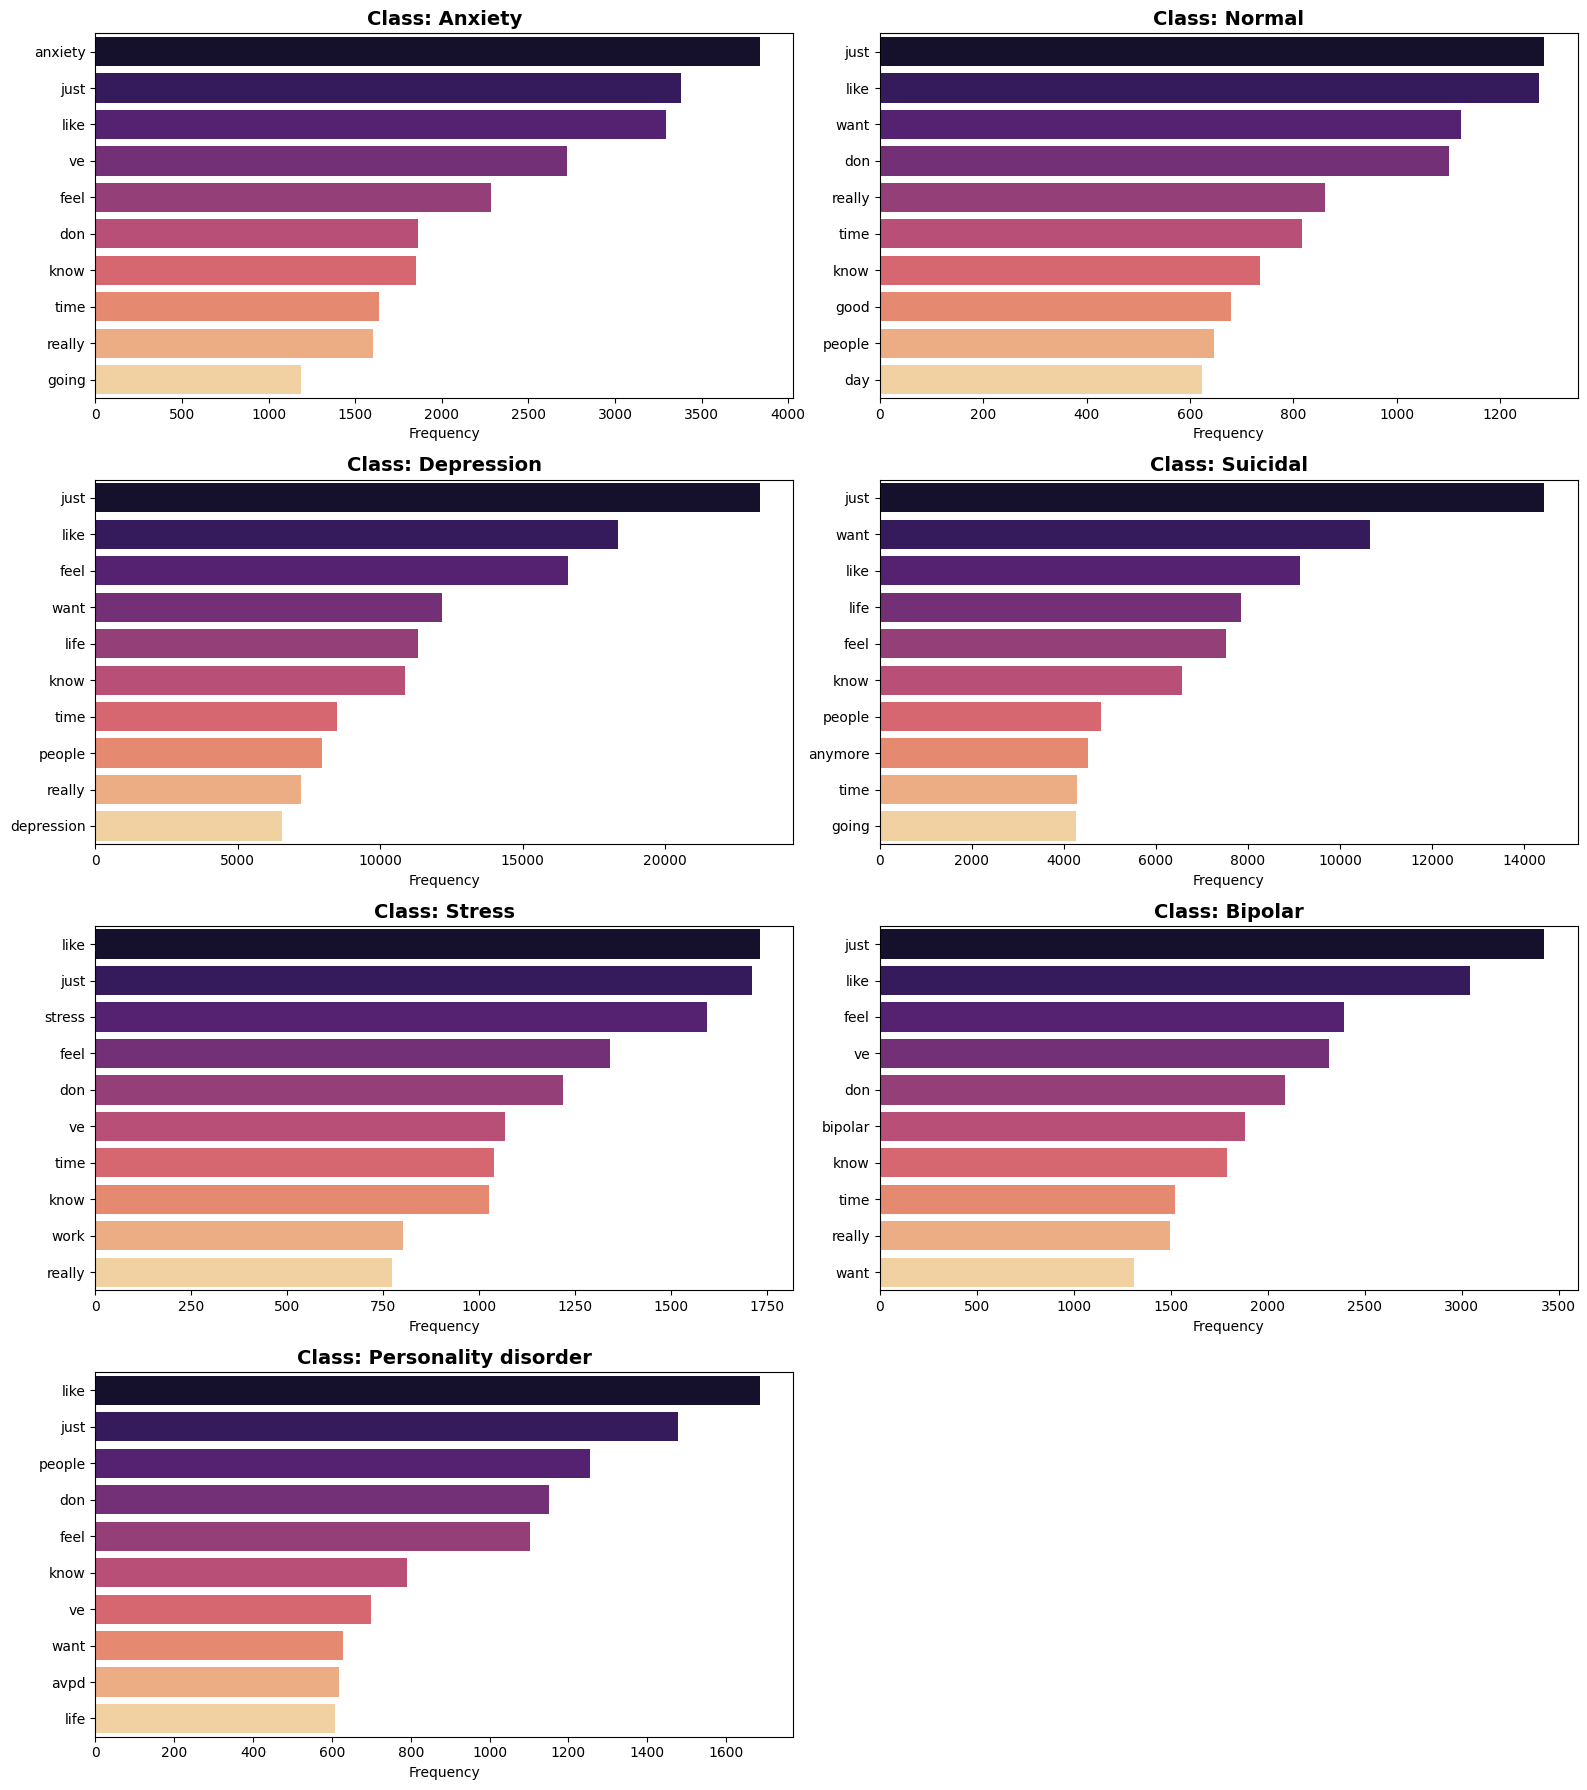

In [ ]:
viz_vectorizer = CountVectorizer(stop_words='english')

classes = df['status'].unique()

fig, axes = plt.subplots(nrows=int(np.ceil(len(classes)/2)), ncols=2, figsize=(16, 18))
axes = axes.flatten()

print("Top 10 Tokens Per Class")

for i, cls in enumerate(classes):
    corpus = df[df['status'] == cls]['clean_statement']

    X = viz_vectorizer.fit_transform(corpus)
    word_freq = pd.DataFrame({
        'word': viz_vectorizer.get_feature_names_out(),
        'freq': X.sum(axis=0).A1
    }).sort_values(by='freq', ascending=False)

    sns.barplot(data=word_freq.head(10), x='freq', y='word', ax=axes[i], palette='magma')
    axes[i].set_title(f'Class: {cls}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Frequency')
    axes[i].set_ylabel('')

# Hide the 8th empty subplot since we only have 7 classes
if len(classes) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [ ]:
df = df.dropna(subset=['statement', 'status']).copy()

In [ ]:
df_clean = df.drop_duplicates(subset=['clean_statement'], keep='first').copy()

print(f"Original row count: {len(df)}")
print(f"Cleaned row count: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Original row count: 52681
Cleaned row count: 51044
Rows removed: 1637


In [ ]:
from sklearn.model_selection import train_test_split


train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    stratify=df_clean['status'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['status'],
    random_state=42
)

print(f"Train Set: {len(train_df)} rows ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"Validation Set: {len(val_df)} rows ({len(val_df)/len(df_clean)*100:.1f}%)")
print(f"Test Set: {len(test_df)} rows ({len(test_df)/len(df_clean)*100:.1f}%)")

Train Set: 35730 rows (70.0%)
Validation Set: 7657 rows (15.0%)
Test Set: 7657 rows (15.0%)


In [ ]:
import json

split_indices = {
    "train_indices": train_df.index.tolist(),
    "val_indices": val_df.index.tolist(),
    "test_indices": test_df.index.tolist()
}

save_path = '/content/drive/MyDrive/mental-health-sentiment/split_indices.json'

with open(save_path, 'w') as f:
    json.dump(split_indices, f)

print(f"Successfully saved frozen split indices to {save_path}")

Successfully saved frozen split indices to /content/drive/MyDrive/mental-health-sentiment/split_indices.json


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def preprocess_text(text, variant='raw'):
    """
    Preprocesses text based on the chosen variant switch.
    Variants: 'raw', 'lower', 'lower_punct_stop', 'lemmatize'
    """
    if pd.isna(text):
        return ""

    if variant == 'raw':
        return text

    text = text.lower()
    if variant == 'lower':
        return text

    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    if variant == 'lower_punct_stop':
        return " ".join(words)

    if variant == 'lemmatize':
        words = [lemmatizer.lemmatize(word) for word in words]
        return " ".join(words)

    return text


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
datasets = {
    'train': train_df,
    'val': val_df,
    'test': test_df
}
variants = ['raw', 'lower', 'lower_punct_stop', 'lemmatize']

for name, data in datasets.items():
    print(f"Processing {name} set...")
    for var in variants:
        col_name = f"statement_{var}"

        data[col_name] = data['statement'].apply(lambda x: preprocess_text(x, variant=var))


display(train_df[['statement', 'statement_lower', 'statement_lower_punct_stop', 'statement_lemmatize']].head(1))

Processing train set...
Processing val set...
Processing test set...


,statement,statement_lower,statement_lower_punct_stop,statement_lemmatize
9671,HeyI think this is going to be sort of long bu...,heyi think this is going to be sort of long bu...,heyi think going sort long need someone know p...,heyi think going sort long need someone know p...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(train_df['statement_lemmatize'])
X_val_tfidf = tfidf.transform(val_df['statement_lemmatize'])
X_test_tfidf = tfidf.transform(test_df['statement_lemmatize'])

y_train = train_df['status']
y_val = val_df['status']
y_test = test_df['status']

print(f"TF-IDF Training shape: {X_train_tfidf.shape}")

TF-IDF Training shape: (35730, 10000)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
import pandas as pd


models_and_configs = {
    "Naive_Bayes": {
        "model": MultinomialNB,
        "configs": [{"alpha": 0.1}, {"alpha": 0.5}, {"alpha": 1.0}]
    },
    "Logistic_Regression": {
        "model": LogisticRegression,
        "configs": [
            {"C": 0.1, "max_iter": 1000, "class_weight": "balanced"},
            {"C": 1.0, "max_iter": 1000, "class_weight": "balanced"},
            {"C": 10.0, "max_iter": 1000, "class_weight": "balanced"}
        ]
    },
    "Random_Forest": {
        "model": RandomForestClassifier,
        "configs": [
            {"n_estimators": 50, "max_depth": 10, "class_weight": "balanced", "random_state": 42},
            {"n_estimators": 100, "max_depth": 20, "class_weight": "balanced", "random_state": 42},
            {"n_estimators": 200, "max_depth": None, "class_weight": "balanced", "random_state": 42}
        ]
    }
}

tuning_results = []
best_models = {}

print("Starting Hyperparameter Tuning Loop...\n")

for model_name, info in models_and_configs.items():
    best_f1 = 0
    best_config = None
    best_trained_model = None

    for i, config in enumerate(info["configs"]):
        clf = info["model"](**config)
        clf.fit(X_train_tfidf, y_train)

        val_preds = clf.predict(X_val_tfidf)

        val_f1 = f1_score(y_val, val_preds, average='macro')

        tuning_results.append({
            "Model": model_name,
            "Config_ID": i + 1,
            "Parameters": str(config),
            "Validation_Macro_F1": val_f1
        })

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_config = config
            best_trained_model = clf

    best_models[model_name] = best_trained_model
    print(f"[{model_name}] Best Val Macro F1: {best_f1:.4f} with config: {best_config}")

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df.sort_values(by="Validation_Macro_F1", ascending=False))

Starting Hyperparameter Tuning Loop...

[Naive_Bayes] Best Val Macro F1: 0.6036 with config: {'alpha': 0.1}
[Logistic_Regression] Best Val Macro F1: 0.6982 with config: {'C': 1.0, 'max_iter': 1000, 'class_weight': 'balanced'}
[Random_Forest] Best Val Macro F1: 0.6394 with config: {'n_estimators': 100, 'max_depth': 20, 'class_weight': 'balanced', 'random_state': 42}


,Model,Config_ID,Parameters,Validation_Macro_F1
4,Logistic_Regression,2,"{'C': 1.0, 'max_iter': 1000, 'class_weight': '...",0.698200
5,Logistic_Regression,3,"{'C': 10.0, 'max_iter': 1000, 'class_weight': ...",0.688135
3,Logistic_Regression,1,"{'C': 0.1, 'max_iter': 1000, 'class_weight': '...",0.676352
7,Random_Forest,2,"{'n_estimators': 100, 'max_depth': 20, 'class_...",0.639382
8,Random_Forest,3,"{'n_estimators': 200, 'max_depth': None, 'clas...",0.615943
0,Naive_Bayes,1,{'alpha': 0.1},0.603620
6,Random_Forest,1,"{'n_estimators': 50, 'max_depth': 10, 'class_w...",0.589282
1,Naive_Bayes,2,{'alpha': 0.5},0.536890
2,Naive_Bayes,3,{'alpha': 1.0},0.485556


In [ ]:
# Cell 15
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

os.makedirs("results", exist_ok=True)

def evaluate_and_save(model_name, y_true, y_pred, classes):
    """
    Evaluates the model, prints required metrics, plots confusion matrix,
    and saves predictions to disk.
    """

    print(f"EVALUATING: {model_name}")

    acc = accuracy_score(y_true, y_pred)
    print(f"Test Accuracy: {acc:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    save_path = f"results/{model_name}_predictions.npy"
    np.save(save_path, y_pred)
    print(f"Saved raw predictions to {save_path}")

EVALUATING: Naive_Bayes
Test Accuracy: 0.6961

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.76      0.70      0.73       542
             Bipolar       0.80      0.67      0.73       375
          Depression       0.57      0.76      0.65      2263
              Normal       0.86      0.82      0.84      2403
Personality disorder       0.91      0.24      0.38       134
              Stress       0.62      0.22      0.32       344
            Suicidal       0.67      0.57      0.62      1596

            accuracy                           0.70      7657
           macro avg       0.74      0.57      0.61      7657
        weighted avg       0.71      0.70      0.69      7657



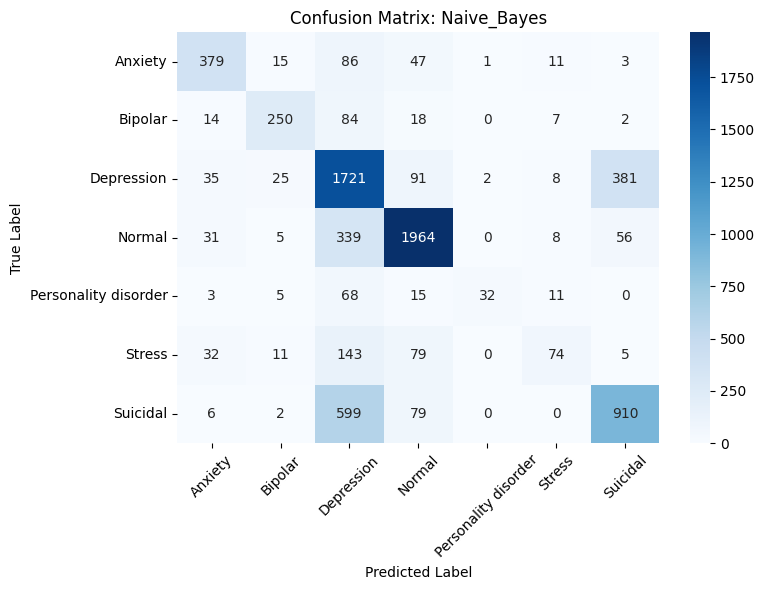

Saved raw predictions to results/Naive_Bayes_predictions.npy
EVALUATING: Logistic_Regression
Test Accuracy: 0.7498

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.78      0.80      0.79       542
             Bipolar       0.73      0.79      0.76       375
          Depression       0.77      0.64      0.70      2263
              Normal       0.88      0.91      0.89      2403
Personality disorder       0.46      0.62      0.53       134
              Stress       0.44      0.64      0.52       344
            Suicidal       0.66      0.68      0.67      1596

            accuracy                           0.75      7657
           macro avg       0.67      0.73      0.69      7657
        weighted avg       0.76      0.75      0.75      7657



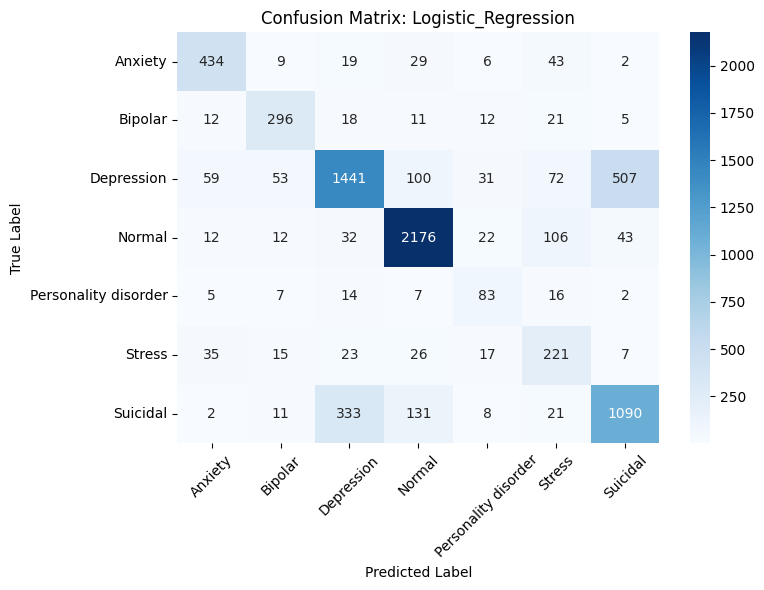

Saved raw predictions to results/Logistic_Regression_predictions.npy
EVALUATING: Random_Forest
Test Accuracy: 0.6828

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.68      0.70      0.69       542
             Bipolar       0.70      0.75      0.72       375
          Depression       0.75      0.51      0.61      2263
              Normal       0.71      0.95      0.81      2403
Personality disorder       0.68      0.45      0.54       134
              Stress       0.50      0.47      0.48       344
            Suicidal       0.60      0.57      0.58      1596

            accuracy                           0.68      7657
           macro avg       0.66      0.63      0.63      7657
        weighted avg       0.68      0.68      0.67      7657



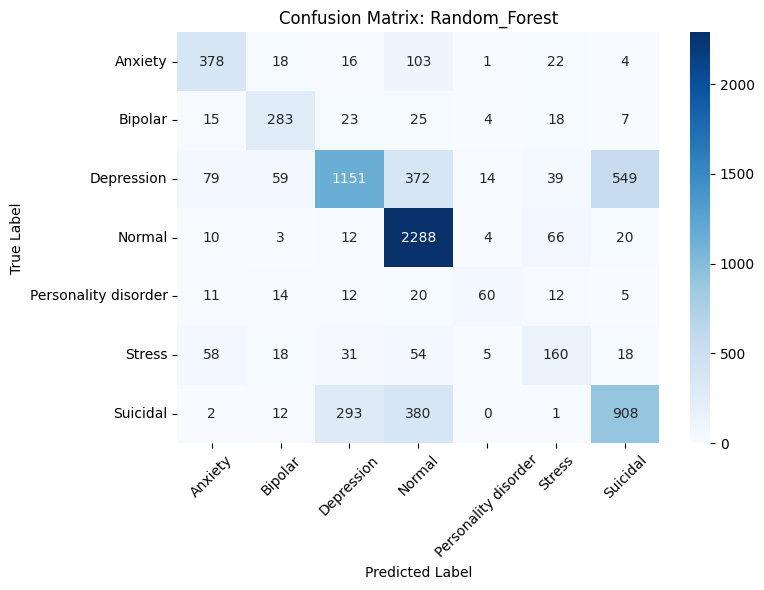

Saved raw predictions to results/Random_Forest_predictions.npy


In [ ]:
class_labels = sorted(test_df['status'].unique())

for model_name, model in best_models.items():
    test_preds = model.predict(X_test_tfidf)

    evaluate_and_save(model_name, y_test, test_preds, class_labels)

In [ ]:
# Cell 17
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import numpy as np

label_encoder = LabelEncoder()
y_train_nn = label_encoder.fit_transform(train_df['status'])
y_val_nn = label_encoder.transform(val_df['status'])
y_test_nn = label_encoder.transform(test_df['status'])


nn_classes = label_encoder.classes_
print("Neural Network Class Mapping:", dict(enumerate(nn_classes)))


max_vocab = 20000
tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_statement'])


X_train_seq = tokenizer.texts_to_sequences(train_df['clean_statement'])
X_val_seq = tokenizer.texts_to_sequences(val_df['clean_statement'])
X_test_seq = tokenizer.texts_to_sequences(test_df['clean_statement'])


max_length = 128
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

print(f"Padded Training Shape: {X_train_pad.shape}")

Neural Network Class Mapping: {0: 'Anxiety', 1: 'Bipolar', 2: 'Depression', 3: 'Normal', 4: 'Personality disorder', 5: 'Stress', 6: 'Suicidal'}
Padded Training Shape: (35730, 128)


In [ ]:
from gensim.models import Word2Vec

sentences = [text.split() for text in train_df['clean_statement']]

w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)



word_index = tokenizer.word_index
vocab_size = min(max_vocab, len(word_index) + 1)
embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))

words_found = 0
for word, i in word_index.items():
    if i >= max_vocab:
        continue
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
        words_found += 1

print(f"Created Embedding Matrix of shape: {embedding_matrix.shape}")
print(f"Found Word2Vec vectors for {words_found} out of {vocab_size} words.")

Created Embedding Matrix of shape: (20000, 100)
Found Word2Vec vectors for 18629 out of 20000 words.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, LSTM, Dense, Dropout
from sklearn.metrics import f1_score
import pandas as pd

rnn_models = {
    "SimpleRNN": SimpleRNN,
    "GRU": GRU,
    "LSTM": LSTM
}

rnn_configs = [
    {"units": 32, "dropout": 0.2, "trainable_emb": True},
    {"units": 64, "dropout": 0.3, "trainable_emb": True},
    {"units": 64, "dropout": 0.3, "trainable_emb": False} # Frozen embedding
]

nn_tuning_results = []
best_nn_models = {}

print("Starting Standard RNN Hyperparameter Tuning Loop...\n")

for model_name, layer_class in rnn_models.items():
    best_f1 = 0
    best_config = None
    best_model = None

    for i, config in enumerate(rnn_configs):
        print(f"Training {model_name} - Config {i+1}...")

        with tf.device('/GPU:0'):
            model = Sequential()

            model.add(Embedding(
                input_dim=vocab_size,
                output_dim=embedding_dim,
                weights=[embedding_matrix],
                input_length=max_length,
                trainable=config["trainable_emb"]
            ))

            model.add(layer_class(config["units"]))
            model.add(Dropout(config["dropout"]))

            model.add(Dense(len(nn_classes), activation='softmax'))

            model.compile(
                loss='sparse_categorical_crossentropy', # labels are integers (0-6)
                optimizer='adam',
                metrics=['accuracy']
            )

            model.fit(
                X_train_pad, y_train_nn,
                validation_data=(X_val_pad, y_val_nn),
                epochs=5,
                batch_size=64,
                verbose=1
            )

        val_probs = model.predict(X_val_pad, verbose=0)
        val_preds = np.argmax(val_probs, axis=1)
        val_f1 = f1_score(y_val_nn, val_preds, average='macro')

        nn_tuning_results.append({
            "Model": model_name,
            "Config_ID": i + 1,
            "Parameters": str(config),
            "Validation_Macro_F1": val_f1
        })

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_config = config
            best_model = model

    best_nn_models[model_name] = best_model
    print(f"[{model_name}] Best Val Macro F1: {best_f1:.4f} with {best_config}\n")

display(pd.DataFrame(nn_tuning_results).sort_values(by="Validation_Macro_F1", ascending=False))

Starting Standard RNN Hyperparameter Tuning Loop...

Training SimpleRNN - Config 1...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.4084 - loss: 1.5695 - val_accuracy: 0.4470 - val_loss: 1.4770
Epoch 2/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.4409 - loss: 1.4817 - val_accuracy: 0.4494 - val_loss: 1.4612
Epoch 3/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.4480 - loss: 1.4547 - val_accuracy: 0.4503 - val_loss: 1.4573
Epoch 4/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.4504 - loss: 1.4436 - val_accuracy: 0.4486 - val_loss: 1.4517
Epoch 5/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.4582 - loss: 1.4173 - val_accuracy: 0.4559 - val_loss: 1.4344
Training SimpleRNN - Config 2...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


559/559 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.4158 - loss: 1.5577 - val_accuracy: 0.4489 - val_loss: 1.4839
Epoch 2/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.4398 - loss: 1.4820 - val_accuracy: 0.4482 - val_loss: 1.4630
Epoch 3/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.4483 - loss: 1.4521 - val_accuracy: 0.4507 - val_loss: 1.4564
Epoch 4/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.4577 - loss: 1.4263 - val_accuracy: 0.4605 - val_loss: 1.4281
Epoch 5/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.4410 - loss: 1.4918 - val_accuracy: 0.4470 - val_loss: 1.4585
Training SimpleRNN - Config 3...
Epoch 1/5


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


559/559 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5386 - loss: 1.1836 - val_accuracy: 0.6086 - val_loss: 0.9306
Epoch 2/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6484 - loss: 0.8550 - val_accuracy: 0.6918 - val_loss: 0.7632
Epoch 3/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7374 - loss: 0.6806 - val_accuracy: 0.7503 - val_loss: 0.6436
Epoch 4/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7890 - loss: 0.5659 - val_accuracy: 0.7588 - val_loss: 0.6046
Epoch 5/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8257 - loss: 0.4828 - val_accuracy: 0.7666 - val_loss: 0.5931
Training LSTM - Config 3...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


559/559 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5127 - loss: 1.2840 - val_accuracy: 0.5759 - val_loss: 1.0776
Epoch 2/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5830 - loss: 0.9835 - val_accuracy: 0.6085 - val_loss: 0.9127
Epoch 3/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6182 - loss: 0.9093 - val_accuracy: 0.6602 - val_loss: 0.8486
Epoch 4/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6640 - loss: 0.8349 - val_accuracy: 0.6816 - val_loss: 0.8057
Epoch 5/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6929 - loss: 0.7866 - val_accuracy: 0.6937 - val_loss: 0.7826
[LSTM] Best Val Macro F1: 0.6555 with {'units': 64, 'dropout': 0.3, 'trainable_emb': True}



,Model,Config_ID,Parameters,Validation_Macro_F1
3,GRU,1,"{'units': 32, 'dropout': 0.2, 'trainable_emb':...",0.696075
4,GRU,2,"{'units': 64, 'dropout': 0.3, 'trainable_emb':...",0.690001
7,LSTM,2,"{'units': 64, 'dropout': 0.3, 'trainable_emb':...",0.655468
5,GRU,3,"{'units': 64, 'dropout': 0.3, 'trainable_emb':...",0.633389
6,LSTM,1,"{'units': 32, 'dropout': 0.2, 'trainable_emb':...",0.510373
8,LSTM,3,"{'units': 64, 'dropout': 0.3, 'trainable_emb':...",0.485382
0,SimpleRNN,1,"{'units': 32, 'dropout': 0.2, 'trainable_emb':...",0.195984
2,SimpleRNN,3,"{'units': 64, 'dropout': 0.3, 'trainable_emb':...",0.168307
1,SimpleRNN,2,"{'units': 64, 'dropout': 0.3, 'trainable_emb':...",0.159181


In [ ]:
from tensorflow.keras.layers import Bidirectional

bi_models = {
    "Bi-SimpleRNN": SimpleRNN,
    "Bi-GRU": GRU,
    "Bi-LSTM": LSTM
}

bi_tuning_results = []
best_bi_models = {}


for model_name, layer_class in bi_models.items():
    best_f1 = 0
    best_config = None
    best_model = None

    for i, config in enumerate(rnn_configs):
        print(f"Training {model_name} - Config {i+1}...")

        with tf.device('/GPU:0'):
            model = Sequential()

            model.add(Embedding(
                input_dim=vocab_size,
                output_dim=embedding_dim,
                weights=[embedding_matrix],
                input_length=max_length,
                trainable=config["trainable_emb"]
            ))

            model.add(Bidirectional(layer_class(config["units"])))

            model.add(Dropout(config["dropout"]))

            model.add(Dense(len(nn_classes), activation='softmax'))

            model.compile(
                loss='sparse_categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy']
            )

            model.fit(
                X_train_pad, y_train_nn,
                validation_data=(X_val_pad, y_val_nn),
                epochs=5,
                batch_size=64,
                verbose=1
            )

            val_probs = model.predict(X_val_pad, verbose=0)
            val_preds = np.argmax(val_probs, axis=1)
            val_f1 = f1_score(y_val_nn, val_preds, average='macro')

            bi_tuning_results.append({
                "Model": model_name,
                "Config_ID": i + 1,
                "Parameters": str(config),
                "Validation_Macro_F1": val_f1
            })

            if val_f1 > best_f1:
                best_f1 = val_f1
                best_config = config
                best_model = model

    best_bi_models[model_name] = best_model
    print(f"[{model_name}] Best Val Macro F1: {best_f1:.4f} with {best_config}\n")

display(pd.DataFrame(bi_tuning_results).sort_values(by="Validation_Macro_F1", ascending=False))

Training Bi-SimpleRNN - Config 1...
Epoch 1/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.4833 - loss: 1.3696 - val_accuracy: 0.5732 - val_loss: 1.1076
Epoch 2/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.5966 - loss: 1.0495 - val_accuracy: 0.6201 - val_loss: 0.9727
Epoch 3/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.6000 - loss: 1.0055 - val_accuracy: 0.6163 - val_loss: 0.9710
Epoch 4/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.6256 - loss: 0.9433 - val_accuracy: 0.6309 - val_loss: 0.9218
Epoch 5/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.6534 - loss: 0.8716 - val_accuracy: 0.5221 - val_loss: 1.2904
Training Bi-SimpleRNN - Config 2...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


559/559 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.5163 - loss: 1.2739 - val_accuracy: 0.6011 - val_loss: 1.0066
Epoch 2/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5942 - loss: 1.0238 - val_accuracy: 0.5710 - val_loss: 1.1247
Epoch 3/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.6228 - loss: 0.9449 - val_accuracy: 0.6371 - val_loss: 0.8969
Epoch 4/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.6470 - loss: 0.8797 - val_accuracy: 0.6450 - val_loss: 0.8803
Epoch 5/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5740 - loss: 1.0878 - val_accuracy: 0.5714 - val_loss: 1.0979
Training Bi-SimpleRNN - Config 3...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


559/559 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.5100 - loss: 1.2973 - val_accuracy: 0.5725 - val_loss: 1.0948
Epoch 2/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5907 - loss: 1.0681 - val_accuracy: 0.5835 - val_loss: 1.0454
Epoch 3/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.5261 - loss: 1.2123 - val_accuracy: 0.5574 - val_loss: 1.1475
Epoch 4/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.5633 - loss: 1.1202 - val_accuracy: 0.5753 - val_loss: 1.0952
Epoch 5/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.5869 - loss: 1.0546 - val_accuracy: 0.5925 - val_loss: 1.0294
[Bi-SimpleRNN] Best Val Macro F1: 0.3837 with {'units': 32, 'dropout': 0.2, 'trainable_emb': True}

Training Bi-GRU - Config 1...
Epoch 1/5


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


559/559 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6473 - loss: 0.8911 - val_accuracy: 0.7238 - val_loss: 0.6926
Epoch 2/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7550 - loss: 0.6244 - val_accuracy: 0.7601 - val_loss: 0.5881
Epoch 3/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7995 - loss: 0.5133 - val_accuracy: 0.7754 - val_loss: 0.5629
Epoch 4/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.8356 - loss: 0.4280 - val_accuracy: 0.7731 - val_loss: 0.5722
Epoch 5/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.8608 - loss: 0.3621 - val_accuracy: 0.7760 - val_loss: 0.5820
Training Bi-LSTM - Config 3...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


559/559 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.6390 - loss: 0.9055 - val_accuracy: 0.7060 - val_loss: 0.7296
Epoch 2/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.7308 - loss: 0.6783 - val_accuracy: 0.7363 - val_loss: 0.6502
Epoch 3/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7598 - loss: 0.6041 - val_accuracy: 0.7558 - val_loss: 0.6080
Epoch 4/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7784 - loss: 0.5561 - val_accuracy: 0.7534 - val_loss: 0.6025
Epoch 5/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7915 - loss: 0.5237 - val_accuracy: 0.7626 - val_loss: 0.5896
[Bi-LSTM] Best Val Macro F1: 0.7134 with {'units': 64, 'dropout': 0.3, 'trainable_emb': True}



,Model,Config_ID,Parameters,Validation_Macro_F1
7,Bi-LSTM,2,"{'units': 64, 'dropout': 0.3, 'trainable_emb':...",0.713431
4,Bi-GRU,2,"{'units': 64, 'dropout': 0.3, 'trainable_emb':...",0.709296
3,Bi-GRU,1,"{'units': 32, 'dropout': 0.2, 'trainable_emb':...",0.701722
6,Bi-LSTM,1,"{'units': 32, 'dropout': 0.2, 'trainable_emb':...",0.691558
5,Bi-GRU,3,"{'units': 64, 'dropout': 0.3, 'trainable_emb':...",0.676007
8,Bi-LSTM,3,"{'units': 64, 'dropout': 0.3, 'trainable_emb':...",0.669421
0,Bi-SimpleRNN,1,"{'units': 32, 'dropout': 0.2, 'trainable_emb':...",0.383748
2,Bi-SimpleRNN,3,"{'units': 64, 'dropout': 0.3, 'trainable_emb':...",0.377682
1,Bi-SimpleRNN,2,"{'units': 64, 'dropout': 0.3, 'trainable_emb':...",0.354364


Evaluating Standard RNNs...
EVALUATING: SimpleRNN
Test Accuracy: 0.4474

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.34      0.10      0.15       542
             Bipolar       0.23      0.04      0.06       375
          Depression       0.49      0.42      0.45      2263
              Normal       0.44      0.99      0.61      2403
Personality disorder       0.00      0.00      0.00       134
              Stress       0.00      0.00      0.00       344
            Suicidal       0.23      0.01      0.02      1596

            accuracy                           0.45      7657
           macro avg       0.25      0.22      0.19      7657
        weighted avg       0.37      0.45      0.34      7657



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


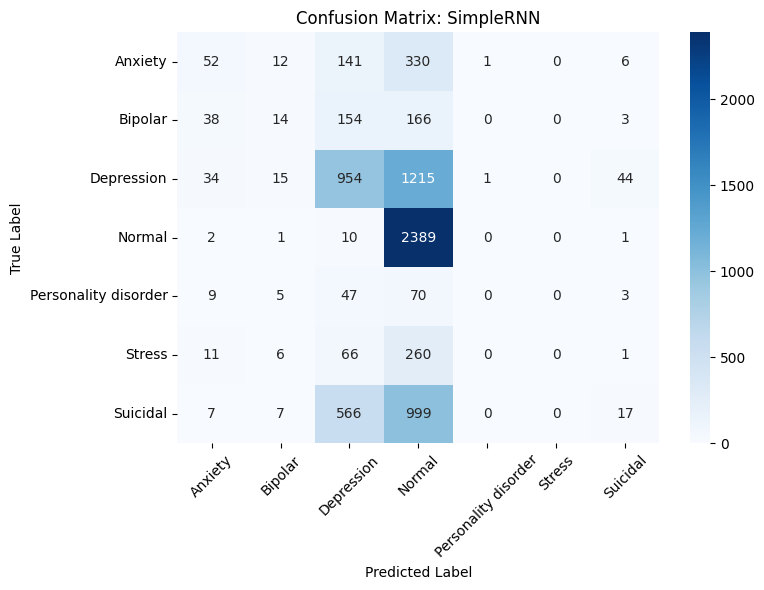

Saved raw predictions to results/SimpleRNN_predictions.npy
EVALUATING: GRU
Test Accuracy: 0.7772

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.75      0.85      0.80       542
             Bipolar       0.76      0.81      0.78       375
          Depression       0.75      0.73      0.74      2263
              Normal       0.93      0.94      0.93      2403
Personality disorder       0.56      0.38      0.45       134
              Stress       0.47      0.47      0.47       344
            Suicidal       0.68      0.67      0.68      1596

            accuracy                           0.78      7657
           macro avg       0.70      0.69      0.69      7657
        weighted avg       0.78      0.78      0.78      7657



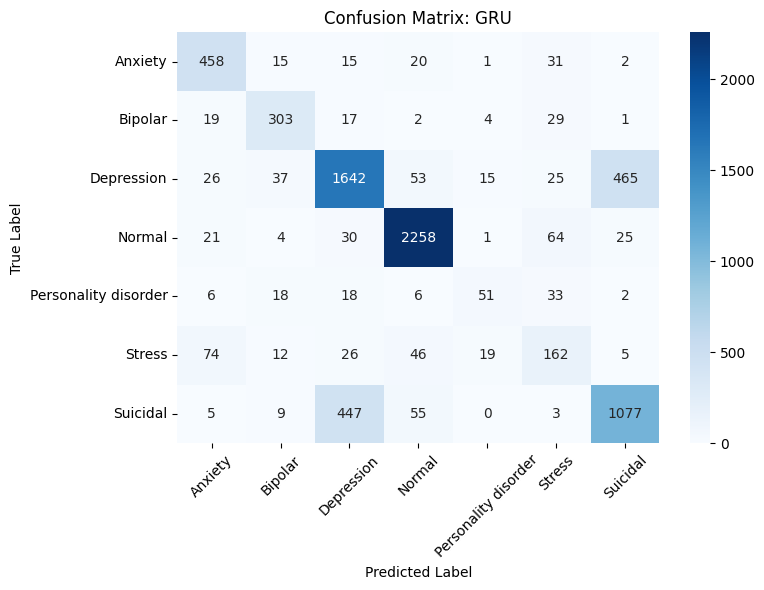

Saved raw predictions to results/GRU_predictions.npy
EVALUATING: LSTM
Test Accuracy: 0.7695

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.73      0.87      0.79       542
             Bipolar       0.82      0.74      0.78       375
          Depression       0.72      0.73      0.73      2263
              Normal       0.93      0.94      0.93      2403
Personality disorder       0.39      0.21      0.27       134
              Stress       0.49      0.47      0.48       344
            Suicidal       0.68      0.66      0.67      1596

            accuracy                           0.77      7657
           macro avg       0.68      0.66      0.66      7657
        weighted avg       0.77      0.77      0.77      7657



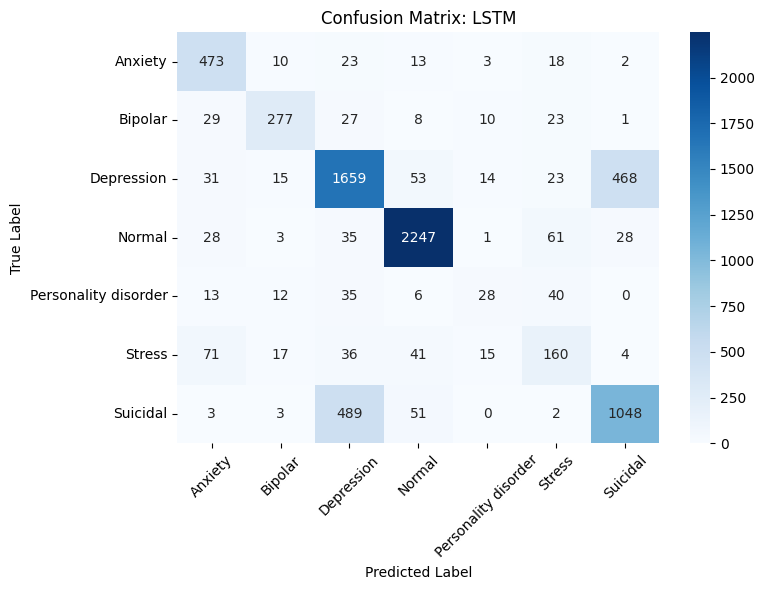

Saved raw predictions to results/LSTM_predictions.npy
Evaluating Bidirectional RNNs...
EVALUATING: Bi-SimpleRNN
Test Accuracy: 0.5234

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.46      0.58      0.51       542
             Bipolar       0.40      0.35      0.37       375
          Depression       0.45      0.81      0.58      2263
              Normal       0.94      0.51      0.66      2403
Personality disorder       0.50      0.03      0.06       134
              Stress       0.37      0.19      0.26       344
            Suicidal       0.39      0.26      0.31      1596

            accuracy                           0.52      7657
           macro avg       0.50      0.39      0.39      7657
        weighted avg       0.59      0.52      0.51      7657



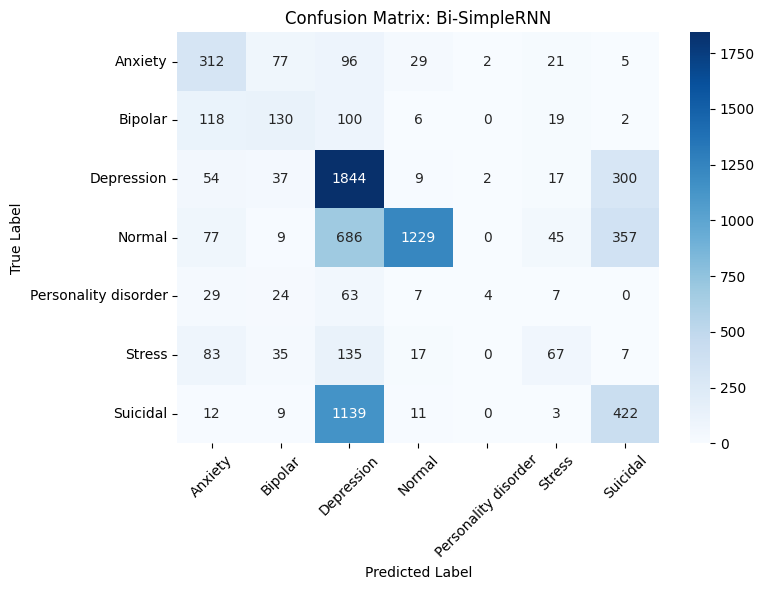

Saved raw predictions to results/Bi-SimpleRNN_predictions.npy
EVALUATING: Bi-GRU
Test Accuracy: 0.7677

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.79      0.84      0.81       542
             Bipolar       0.72      0.82      0.77       375
          Depression       0.77      0.63      0.69      2263
              Normal       0.94      0.93      0.93      2403
Personality disorder       0.54      0.56      0.55       134
              Stress       0.56      0.52      0.54       344
            Suicidal       0.62      0.76      0.68      1596

            accuracy                           0.77      7657
           macro avg       0.70      0.72      0.71      7657
        weighted avg       0.78      0.77      0.77      7657



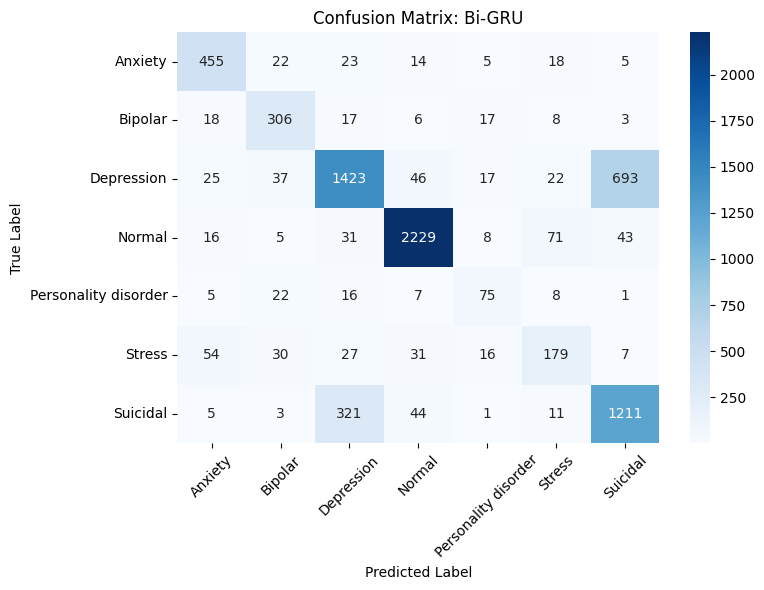

Saved raw predictions to results/Bi-GRU_predictions.npy
EVALUATING: Bi-LSTM
Test Accuracy: 0.7839

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.84      0.80      0.82       542
             Bipolar       0.84      0.73      0.78       375
          Depression       0.70      0.80      0.75      2263
              Normal       0.94      0.94      0.94      2403
Personality disorder       0.48      0.44      0.46       134
              Stress       0.54      0.60      0.57       344
            Suicidal       0.72      0.60      0.66      1596

            accuracy                           0.78      7657
           macro avg       0.72      0.70      0.71      7657
        weighted avg       0.79      0.78      0.78      7657



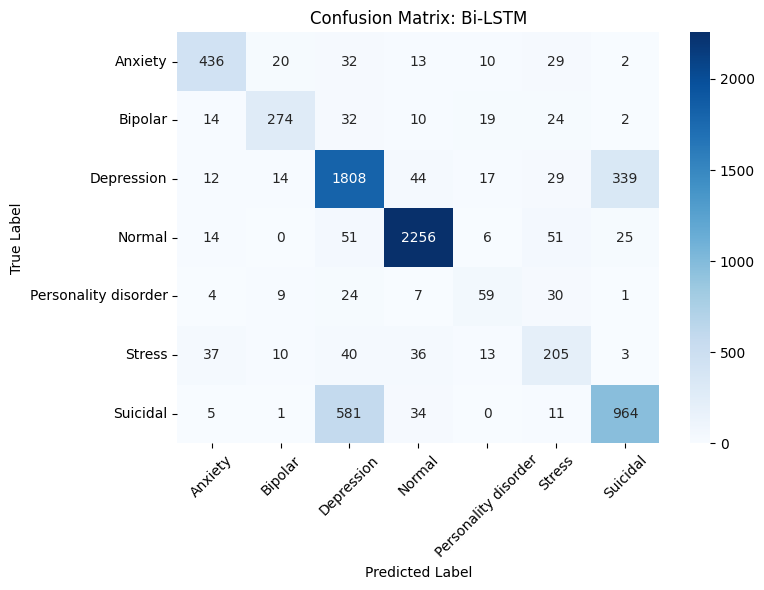

Saved raw predictions to results/Bi-LSTM_predictions.npy


In [ ]:
print("Evaluating Standard RNNs...")
for model_name, model in best_nn_models.items():
    test_probs = model.predict(X_test_pad, verbose=0)

    test_preds_int = np.argmax(test_probs, axis=1)

    test_preds_str = label_encoder.inverse_transform(test_preds_int)
    y_test_str = label_encoder.inverse_transform(y_test_nn)

    evaluate_and_save(model_name, y_test_str, test_preds_str, class_labels)

print("Evaluating Bidirectional RNNs...")
for model_name, model in best_bi_models.items():
    test_probs = model.predict(X_test_pad, verbose=0)

    test_preds_int = np.argmax(test_probs, axis=1)

    test_preds_str = label_encoder.inverse_transform(test_preds_int)
    evaluate_and_save(model_name, y_test_str, test_preds_str, class_labels)

In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset
import pandas as pd

train_hf = Dataset.from_pandas(pd.DataFrame({'text': train_df['clean_statement'], 'label': y_train_nn}))
val_hf = Dataset.from_pandas(pd.DataFrame({'text': val_df['clean_statement'], 'label': y_val_nn}))
test_hf = Dataset.from_pandas(pd.DataFrame({'text': test_df['clean_statement'], 'label': y_test_nn}))

model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing datasets...")
train_tokenized = train_hf.map(tokenize_function, batched=True)
val_tokenized = val_hf.map(tokenize_function, batched=True)
test_tokenized = test_hf.map(tokenize_function, batched=True)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizing datasets...


Map:   0%|          | 0/35730 [00:00<?, ? examples/s]

Map:   0%|          | 0/7657 [00:00<?, ? examples/s]

Map:   0%|          | 0/7657 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, predictions, average='macro')
    return {"macro_f1": macro_f1}

bert_configs = [
    {"learning_rate": 2e-5, "batch_size": 16, "epochs": 2},
    {"learning_rate": 3e-5, "batch_size": 32, "epochs": 3},
    {"learning_rate": 5e-5, "batch_size": 16, "epochs": 3}
]

bert_tuning_results = []
best_bert_f1 = 0
best_bert_config = None
best_bert_trainer = None

print("Starting BERT Base Hyperparameter Tuning Loop...\n")

for i, config in enumerate(bert_configs):
    print(f"\nTraining BERT - Config {i+1}: {config}")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=len(nn_classes)
    )

    training_args = TrainingArguments(
        output_dir=f"./results_bert_config_{i+1}",
        learning_rate=config["learning_rate"],
        per_device_train_batch_size=config["batch_size"],
        per_device_eval_batch_size=config["batch_size"],
        num_train_epochs=config["epochs"],
        eval_strategy="epoch",       # Evaluate at the end of every epoch
        save_strategy="epoch",       # Save checkpoints at the end of every epoch
        load_best_model_at_end=True, # Automatically load the best epoch weights
        metric_for_best_model="macro_f1",
        fp16=True,                   # Use mixed precision to speed up T4 GPU training
        report_to="none"             # Disable logging to W&B
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        compute_metrics=compute_metrics
    )

    trainer.train()

    eval_results = trainer.evaluate()
    val_f1 = eval_results["eval_macro_f1"]


    bert_tuning_results.append({
        "Model": "BERT-Base",
        "Config_ID": i + 1,
        "Parameters": str(config),
        "Validation_Macro_F1": val_f1
    })

    if val_f1 > best_bert_f1:
        best_bert_f1 = val_f1
        best_bert_config = config
        best_bert_trainer = trainer

print(f"\n[BERT-Base] Best Val Macro F1: {best_bert_f1:.4f} with {best_bert_config}\n")
display(pd.DataFrame(bert_tuning_results).sort_values(by="Validation_Macro_F1", ascending=False))

Starting BERT Base Hyperparameter Tuning Loop...


Training BERT - Config 1: {'learning_rate': 2e-05, 'batch_size': 16, 'epochs': 2}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.473195,0.464304,0.774730
2,0.353915,0.444346,0.788869


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Macro F1
0.202891,0.543821,3,0.791611



[BERT-Base] Best Val Macro F1: 0.7916 with {'learning_rate': 5e-05, 'batch_size': 16, 'epochs': 3}



,Model,Config_ID,Parameters,Validation_Macro_F1
2,BERT-Base,3,"{'learning_rate': 5e-05, 'batch_size': 16, 'ep...",0.791611
1,BERT-Base,2,"{'learning_rate': 3e-05, 'batch_size': 32, 'ep...",0.791033
0,BERT-Base,1,"{'learning_rate': 2e-05, 'batch_size': 16, 'ep...",0.788869


In [ ]:
import os
import joblib

drive_save_path = '/content/drive/MyDrive/mental-health-sentiment'
os.makedirs(drive_save_path, exist_ok=True)

best_bert_trainer.save_model(f"{drive_save_path}/best_bert")
tokenizer.save_pretrained(f"{drive_save_path}/best_bert")

best_bi_models["Bi-LSTM"].save(f"{drive_save_path}/best_bilstm.h5")

joblib.dump(best_models["Logistic_Regression"], f"{drive_save_path}/best_logreg.pkl")

joblib.dump(tfidf, f"{drive_save_path}/tfidf_vectorizer.pkl")
joblib.dump(label_encoder, f"{drive_save_path}/label_encoder.pkl")

print(f"Success! All assets safely backed up to: {drive_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Success! All assets safely backed up to: /content/drive/MyDrive/mental-health-sentiment
